# Circuit analysis - monkey N

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from itertools import combinations
from scipy.stats import mannwhitneyu
from matplotlib.colors import Normalize

## Parameters

In [3]:
NAMES_COLORS = {'DOWN_narrow_shallow': 'maroon',
         'DOWN_narrow_sharp': 'red',
         'DOWN_medium_shallow': 'orange',
         'DOWN_medium_sharp': 'yellow',
         'DOWN_wide': 'blue',
         'UP': 'green',}

In [4]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params_analysis = yaml.safe_load(f)

DATA_FOLDER = params_analysis['data_folder'] ### folder with all the preprocessed data
DATES = params_analysis['dates']

DF_FOLDER = '/CSNG/studekat/ripple_band_project/dataframes' ### here the resulting dataframes will be saved
MONKEY_LIST = ['N'] 
AREAS_MERGED = params_analysis['areas_merged']
FINAL_CLASSES = params_analysis['final_classes']
CLASS_COLORS = params_analysis['colors_class']
CLASS_NAMES = params_analysis['classes_names']
AREAS = params_analysis['areas']

AREA = 'V12'
SEL_TH = params_analysis['select_th']
DUAL_TH = [2.5,3.5]

In [5]:
NAMES_COLORS = {'DOWN_narrow_shallow': 'maroon',
         'DOWN_narrow_sharp': 'red',
         'DOWN_medium_shallow': 'orange',
         'DOWN_medium_sharp': 'yellow',
         'DOWN_wide': 'blue',
         'UP': 'green',}

In [6]:
CELL_PAIRS_MAPPING = {'maroon_blue': 'NarrBI+Wide',
                      'orange_maroon': 'MedBI+NarrBI',
                      'orange_blue': 'MedBI+Wide',
                      'red_green': 'NarrTRI+Pos',
                      'green_green': 'Pos+Pos',
                      'yellow_yellow': 'MedTRI+MedTRI',
                      'red_red': 'NarrTRI+NarrTRI',
                      'blue_blue': 'Wide+Wide',
                      'orange_orange': 'MedBI+MedBI',
                      'maroon_maroon': 'NarrBI+NarrBI',
                      'blue_green': 'Wide+Pos',
                      'maroon_green': 'NarrBI+Pos',
                      'maroon_red': 'NarrBI+NarrTRI',
                      'orange_green': 'MedBI+Pos',
                      'orange_red': 'MedBI+NarrTRI',
                      'orange_yellow': 'MedBI+MedTRI',
                      'red_blue': 'NarrTRI+Wide',
                      'yellow_blue': 'MedTRI+Wide',
                      'yellow_green': 'MedTRI+Pos',
                      'yellow_red': 'MedTRI+NarrTRI',
                      'yellow_maroon': 'MedTRI+NarrBI'
                     }

## Functions

In [7]:
def count_num_cells_ch(ch_arr, cl_arr):
    """
    Auxiliary. 
    Counts numbers of cells of each class.
    """
    num_cells_dict = {}
    classes_cells_dict = {}
    for ch in range(64):
        cell_idx_ch = np.where(ch_arr==ch)[0]
        num_cells_ch = len(cell_idx_ch)
        num_cells_dict[ch] = num_cells_ch
        if num_cells_ch>0:
            classes_cells_dict[ch] = cl_arr[cell_idx_ch]
        else:
            classes_cells_dict[ch] = []
    
    return num_cells_dict, classes_cells_dict

In [8]:
def plot_num_cells_ch(list_num_dicts,title='Cell group counts'):
    """
    Plotting the number of cell type counds as a barplot.
    """
    list_all_nums = []
    for d in list_num_dicts:
        list_all_nums.append(list(d.values()))
    list_all_nums = list_merge(list_all_nums)
    
    unique_counts = {item: list_all_nums.count(item) for item in set(list_all_nums)}
    keys = list(unique_counts.keys())
    vals = list(unique_counts.values())

    fig, ax = plt.subplots()
    fig.set_figwidth(4)
    fig.set_figheight(4)

    plt.suptitle(title)

    # Normalize values for colormap
    norm = plt.Normalize(min(vals), max(vals))
    colors = plt.cm.viridis(norm(vals))  

    bars = plt.bar(keys, vals, color=colors)

    # Text - num. cells above each barplot
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Num. cells in group')
    ax.set_ylabel('Num. groups of given count')
    #print(max(keys))
    ax.set_xticks(range(max(keys)+1))
    ax.set_xticklabels(range(max(keys)+1))
    plt.show()
    plt.close()
    return

In [9]:
def aux_group_data(spikes_arr,ch_arr,cl_arr, rb_env_arr=None):
    """
    Return three lists:
    List of spike arrays of N rows if N>1 (multiple cells on one channel),
    The corresponding classes of cells are in the second list,
    List of channels where the activity is.
    """

    ch_list = ch_arr.flatten().tolist()
    
    unique_counts = {item: ch_list.count(item) for item in set(ch_list)}
    keys = np.array(list(unique_counts.keys()))
    vals = np.array(list(unique_counts.values()))

    ch_more_cells = keys[vals>1]
    spikes_list = []
    class_list = []
    channel_list = []
    if rb_env_arr is not None:
        rb_env_list = []
    for ch in ch_more_cells:
        ch_idx = np.where(ch_arr==ch)[0]
        sp_group_arr = spikes_arr[ch_idx,:]  # Only the spike activity of the given group of cells
        if rb_env_arr is not None:
            rb_group_arr = rb_env_arr[ch_idx,:]  # The corresponding RB envelope
        cl_group_arr = cl_arr[ch_idx,:]  # Classes of the cells within the group
        cl_group_arr = cl_group_arr.flatten()
        spikes_list.append(sp_group_arr)
        class_list.append(cl_group_arr)
        channel_list.append(ch)
        if rb_env_arr is not None:
            rb_env_list.append(rb_group_arr)
    
    if rb_env_arr is not None:
        return spikes_list, class_list, channel_list, rb_env_list
    else:
        return spikes_list, class_list, channel_list, None

In [10]:
def plot_raster(spike_arr,cl_names,win_width,num_wins=None,colors_dict=CLASS_COLORS):
    """
    Plotting example activity of the group of cells.
    """
    if num_wins == None:
        num_wins = int(spike_arr.shape[1]//win_width)
    for i in range(num_wins):
        start_idx = i*win_width
        stop_idx = (i+1)*win_width
        aux_plot_activity(spike_arr[:,start_idx:stop_idx],cl_names,colors_dict)

    return

In [11]:
def aux_plot_activity(spike_win,cl_names,colors_dict):
    """
    Plotting color-coded activity of group of cells in one window.
    """
    
    fig, ax = plt.subplots()
    fig.set_figheight(1)
    fig.set_figwidth(14)

    spike_times = []
    for row in range(len(cl_names)):
        spike_times.append(np.where(spike_win[row,:]>0)[0])  #converting spikes to indices
    
    colors = [colors_dict[n] for n in cl_names]
    
    ax.eventplot(spike_times, colors=colors) #, lineoffsets=[1, 2], linelengths=0.8)
    ax.set_yticks(range(len(cl_names)), [f'Cell {i}' for i in range(len(cl_names))])  
    ax.set_xlabel('Time [ms]')

    plt.show()
    plt.close()
    return

In [12]:
def find_spike_distances(sp_vec0, sp_vec1):
    """
    Calculates the distance of the spike to its nearest neighbour.
    """    
    idx1 = np.where(sp_vec0>0)[0]  # spike indices
    idx2 = np.where(sp_vec1>0)[0]
    
    # Compute minimal positive/negative distance from each spike in vec0 to any spike in vec1
    min_pos_distances = []  # distances from each spike in vec 1 to its closest RIGHT neighbour in vec 1 
    min_neg_distances = [] # distances from each spike in vec 1 to its closest LEFT neighbour in vec 1 
    for i in idx1:
        distances = idx2 - i
        pos_distances = distances[distances>=0]
        neg_distances = distances[distances<0]
        #print(pos_distances)
        #print(neg_distances)
        try:
            min_pos_distances.append(np.min(pos_distances))
        except:
            pass # the last spike has no pos. distance
        try:
            min_neg_distances.append(np.max(neg_distances))
        except:
            pass # the first spike has no neg. distance
            
    return min_pos_distances, min_neg_distances

In [13]:
def shuffle_spike_distances(spikes_0, spikes_1,repeat=100):
    """
    Shuffle control for spike dist. 
    """
    #### WE ROLL ONE OF THE SPIKE VECTORS REPEATEDLY
    shifts = np.random.randint(0, len(spikes_0),size=repeat)
    all_rolled = [np.roll(spikes_0, shifts[_]) for _ in range(repeat)]  # list of rolled copies of vector 0
    dist_list = [list_merge(find_spike_distances(rolled, spikes_1)) for rolled in all_rolled]
    return list_merge(dist_list)

In [14]:
def plot_dist_hist(min_pos,min_neg,shuffled_dist,cell_classes,class_colors,
                   buffer=15,title=''):
    """
    Plotting distribution of lags against the shuffle.
    """

    fig, ax = plt.subplots()
    fig.set_figwidth(3)
    fig.set_figheight(2)
    
    plt.title(title,fontsize=10)

    ax.text(0.5, -.25, cell_classes[0], color=class_colors[cell_classes[0]], transform=ax.transAxes,
            ha='right', va='bottom', fontsize=10)
    ax.text(0.5, -.25, cell_classes[1], color=class_colors[cell_classes[1]], transform=ax.transAxes,
            ha='left', va='bottom', fontsize=10)
    
    all_dist = list_merge([min_pos,min_neg])
    all_dist = np.array(all_dist)
    shuffled_dist = np.array(shuffled_dist)
    # masking real data
    mask = (all_dist>-buffer) & (all_dist<buffer)
    zoom_dist = all_dist[mask]
    # masking shuffle
    mask_sh = (shuffled_dist>-buffer) & (shuffled_dist<buffer)
    zoom_dist_sh = shuffled_dist[mask_sh]
    
    ax.hist(zoom_dist,bins=2*buffer-1,alpha=0.8,density=True)
    ax.hist(zoom_dist_sh,bins=2*buffer-1,alpha=0.4,density=True,color='gray')
    ax.axvline(np.median(zoom_dist),color='darkblue',alpha=0.8,ls='dashed')
    ax.axvline(0,color='gray',alpha=0.8,ls='dashed')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.show()
    plt.close()
    return

In [15]:
def find_peak(min_pos, min_neg,width_lag=10):
    """
    Finding the maximal lag and its value as measure in units of histogram density.
    """
    all_dist = list_merge([min_pos,min_neg])
    
    # creating bins centered at each integer number, corresponding to lags
    bin_centers = np.arange(-width_lag, width_lag+1, 1) 
    bin_edges = bin_centers - 0.5
    bin_edges = np.append(bin_edges, bin_centers[-1] + 0.5)  # add final edge
    
    counts, bin_edges = np.histogram(all_dist,bins=bin_edges,density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    max_lag = bin_centers[np.argmax(counts)]
    val_max_lag = np.max(counts)
    return max_lag, val_max_lag

In [16]:
def find_density_at_lag(vals,lag,width_lag=10):
    """
    Finds the value of density in the histogram at a given lag (bin).
    """
    all_dist = np.array(vals)
    
    # creating bins centered at each integer number, corresponding to lags
    bin_centers = np.arange(-width_lag, width_lag+1, 1) 
    bin_edges = bin_centers - 0.5
    bin_edges = np.append(bin_edges, bin_centers[-1] + 0.5)  # add final edge
    
    counts, bin_edges = np.histogram(all_dist,bins=bin_edges,density=True)
    #bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    lag_idx = np.where(bin_centers==lag)
    density_at_lag = counts[lag_idx]
    return density_at_lag

In [17]:
def find_median(min_pos,min_neg,width_lag=10):
    """
    Finding the maximal lag and its value as measure in units of histogram density.
    """
    all_dist = list_merge([min_pos,min_neg])
    all_dist = np.array(all_dist)
    mask = (all_dist>-width_lag) & (all_dist<width_lag)
    zoom_dist = all_dist[mask]
    med = np.median(zoom_dist)
    return med

## Testing against surrogate distributions

In [18]:
data_dicts = []
for monkey in MONKEY_LIST:
    print(monkey)
    for date in DATES[monkey]['NATIM']:
        try:
            print(date)
            file_path = f'/CSNG/studekat/ripple_band_project/dataframes/shuffle_cell_pairs_bin_05_NATIM/{monkey}_{date}_N_1000_width_20.pkl'
            with open(file_path, "rb") as f:
                loaded_data = pickle.load(f)
            data_dicts.append(loaded_data)
        except:
            print(f'For date {date} the data were not used.')

data_merged = list_merge(data_dicts)

N
20220111_B1
20220111_B2
20220111_B3
20220111_B4
20220111_B5
20220111_B6
20220111_B7
20220111_B8
20220111_B9
20220111_B10
For date 20220111_B10 the data were not used.
20220112_B1
20220112_B2
20220112_B3
20220112_B4
20220112_B5
20220112_B6
20220112_B7
20220112_B8
20220112_B9
20220112_B10
For date 20220112_B10 the data were not used.
20220112_B11
20220113_B1
20220113_B2
20220113_B3
20220113_B4
20220114_B1
20220114_B2
20220114_B3


In [19]:
for d in data_merged:
    d['perc_95_max_shuffle'] = np.percentile(d['max_density_shuffle'],95)
    d['perc_95_lag_shuffle'] = np.percentile(d['lag_density_shuffle'],95)
    d['signif_at_lag'] = d['val_max_lag'] > np.percentile(d['lag_density_shuffle'],95)
    d['signif_at_max'] = d['val_max_lag'] > np.percentile(d['max_density_shuffle'],95)

In [20]:
to_df_list = []
list_cols = ['monkey','date','class_names','signif_at_lag','signif_at_max','max_lag']
for d in data_merged:
    new_d = {key:d[key] for key in list_cols}
    to_df_list.append(new_d)

df_pairs = pd.DataFrame(to_df_list)

In [21]:
# sorting names
sorted_names = [sorted(arr) for arr in df_pairs['class_names']]
# changing the sign of the lag is we changed the order of the cells
sorted_lags = []
#sorted_colors = []
num_turned = 0
turned_bool = []
for i in range(len(df_pairs['max_lag'])):
    if df_pairs.iloc[i]['class_names'][0] == sorted_names[i][0]:
        sorted_lags.append(df_pairs['max_lag'][i])
        #sorted_lags.append(all_groups_medians[i])
        #sorted_colors.append([all_groups_colors[i][0],all_groups_colors[i][1]])
        turned_bool.append(False)
    else:
        sorted_lags.append(-df_pairs['max_lag'][i])
        #sorted_lags.append(-all_groups_medians[i])
        #sorted_colors.append([all_groups_colors[i][1],all_groups_colors[i][0]])
        num_turned+=1
        turned_bool.append(True)
print(num_turned)

556


In [22]:
df_pairs['sorted_lags'] = sorted_lags
df_pairs['sorted_names'] = sorted_names
df_pairs['turned'] = turned_bool

In [23]:
# adding colors to sorted names
sorted_colors = []
final_names = []
for name in sorted_names:
    list_colors = [NAMES_COLORS[name[0]],NAMES_COLORS[name[1]]]
    sorted_colors.append(list_colors)
    final_names.append('_'.join(list_colors))

In [24]:
df_pairs['sorted_colors'] = sorted_colors
df_pairs['pair_class'] = final_names

## Numbers of cells visualisation

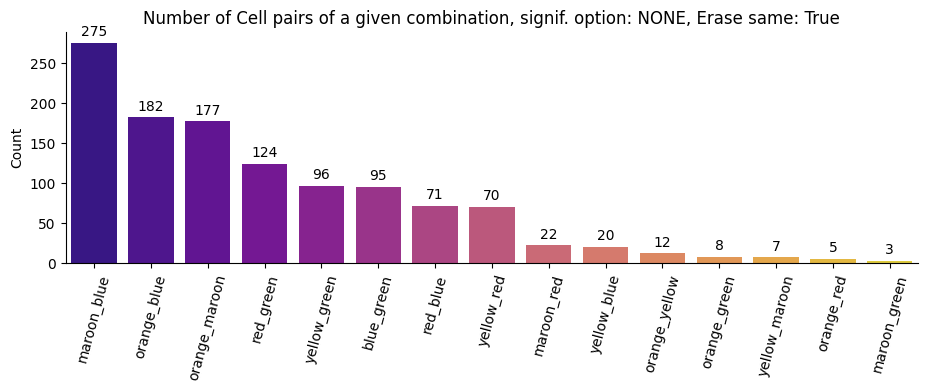

In [25]:
erase_same_cl = True
erase_small_gr = False

only_max_signif = False
only_lag_signif = False
both_signif = False

lag_name = 'sorted_lags'

fig, ax = plt.subplots(1,1)
fig.set_figwidth(11)
fig.set_figheight(3)


# FILTERING BASED ON SIGNIFICANCE OF LAGS
if only_max_signif:
    signif_option = 'MAX'
    df = df_pairs[df_pairs['signif_at_max']] 
elif only_lag_signif:
    signif_option = 'LAG'
    df = df_pairs[df_pairs['signif_at_lag']]
elif both_signif:
    signif_option = 'BOTH'
    df = df_pairs[df_pairs['signif_at_max']]
    df = df[df['signif_at_lag']]
else:
    signif_option = 'NONE'
    df = df_pairs

same_groups = ['green_green','yellow_yellow','red_red','blue_blue','orange_orange','maroon_maroon']
small_groups = ['blue_green','maroon_green','maroon_red','orange_green','orange_red',
                'orange_yellow','red_blue','yellow_blue','yellow_green','yellow_red']

if erase_same_cl:  # not showing lags between the same type of units
    df = df[~df['pair_class'].isin(same_groups)]

if erase_small_gr:
    df = df[~df['pair_class'].isin(small_groups)]

count_df = df['pair_class'].value_counts().reset_index()
count_df.columns = ['pair_class', 'Count']
#count_df = count_df.sort_values('pair_class')  # Ensure consistent order

# Barplot of cell counts
b = sns.barplot(data=count_df, hue='pair_class',x='pair_class', y='Count', ax=ax, palette='plasma')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.set_title(f'Number of Cell pairs of a given combination, signif. option: {signif_option}, Erase same: {erase_same_cl}')

ax.tick_params(axis='x', labelrotation=75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add labels above each bar
for container in b.containers:
    ax.bar_label(container, label_type='edge', padding=3)

#plt.tight_layout()
plt.show()
plt.close()

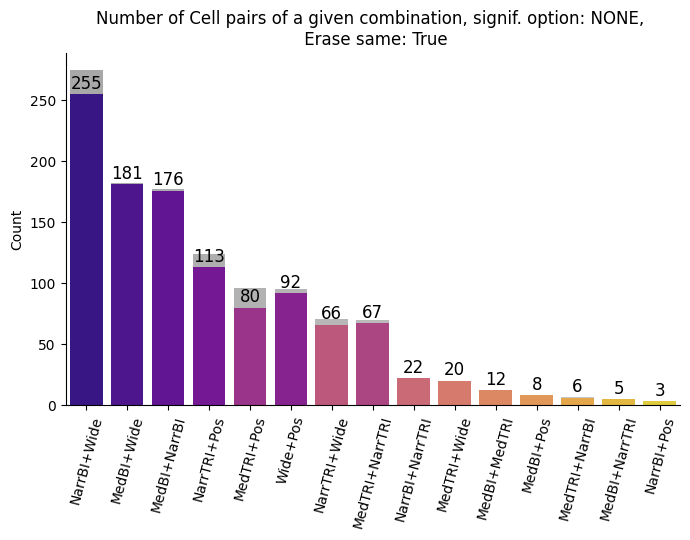

In [26]:
### overlapping bars
erase_same_cl = True
erase_small_gr = False

lag_name = 'sorted_lags'
df_lag_signif = df_pairs[df_pairs['signif_at_lag']]  ### non-signif compared with signif at lag

fig, ax = plt.subplots(1,1)
fig.set_figwidth(7)
fig.set_figheight(5.5)

same_groups = ['green_green','yellow_yellow','red_red','blue_blue','orange_orange','maroon_maroon']
small_groups = ['blue_green','maroon_green','maroon_red','orange_green','orange_red',
                'orange_yellow','red_blue','yellow_blue','yellow_green','yellow_red']

if erase_same_cl:  # not showing lags between the same type of units
    df = df[~df['pair_class'].isin(same_groups)]
    df_lag_signif = df_lag_signif[~df_lag_signif['pair_class'].isin(same_groups)]

if erase_small_gr:
    df = df[~df['pair_class'].isin(small_groups)]
    df_lag_signif = df_lag_signif[~df_lag_signif['pair_class'].isin(small_groups)]

# renaming
pair_new_class = []
for idx in count_df.index:
    pair_cl = count_df.loc[idx]['pair_class']
    pair_new_class.append(CELL_PAIRS_MAPPING[pair_cl])
count_df['new_pair_class'] = pair_new_class

count_df_signif = df_lag_signif['pair_class'].value_counts().reset_index()
count_df_signif.columns = ['pair_class', 'Count']

# renaming
pair_new_class = []
for idx in count_df_signif.index:
    pair_cl = count_df_signif.loc[idx]['pair_class']
    pair_new_class.append(CELL_PAIRS_MAPPING[pair_cl])
count_df_signif['new_pair_class'] = pair_new_class

# Barplot of cell counts
bb = sns.barplot(data=count_df, hue='pair_class',x='new_pair_class', y='Count', palette='dark:gray',alpha=0.4)

"""
# Add labels above each bar
for container in bb.containers:
    ax.bar_label(container, label_type='center', padding=2,color='k',fontsize=12)
"""

# Save current containers count
existing_containers = len(ax.containers)

# Overlay foreground bars (significant)
b = sns.barplot(data=count_df_signif, hue='pair_class',x='new_pair_class', y='Count', palette='plasma',alpha=1)

# Label only new containers added by b
new_containers = ax.containers[existing_containers:]
for container in new_containers:
    ax.bar_label(container, label_type='edge', padding=1, color='k', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.set_title(f'Number of Cell pairs of a given combination, signif. option: {signif_option}, \n Erase same: {erase_same_cl}')

ax.tick_params(axis='x', labelrotation=75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

b.legend_.remove()
plt.tight_layout()
plt.show()
plt.close()

## Lags for the most numerous classes

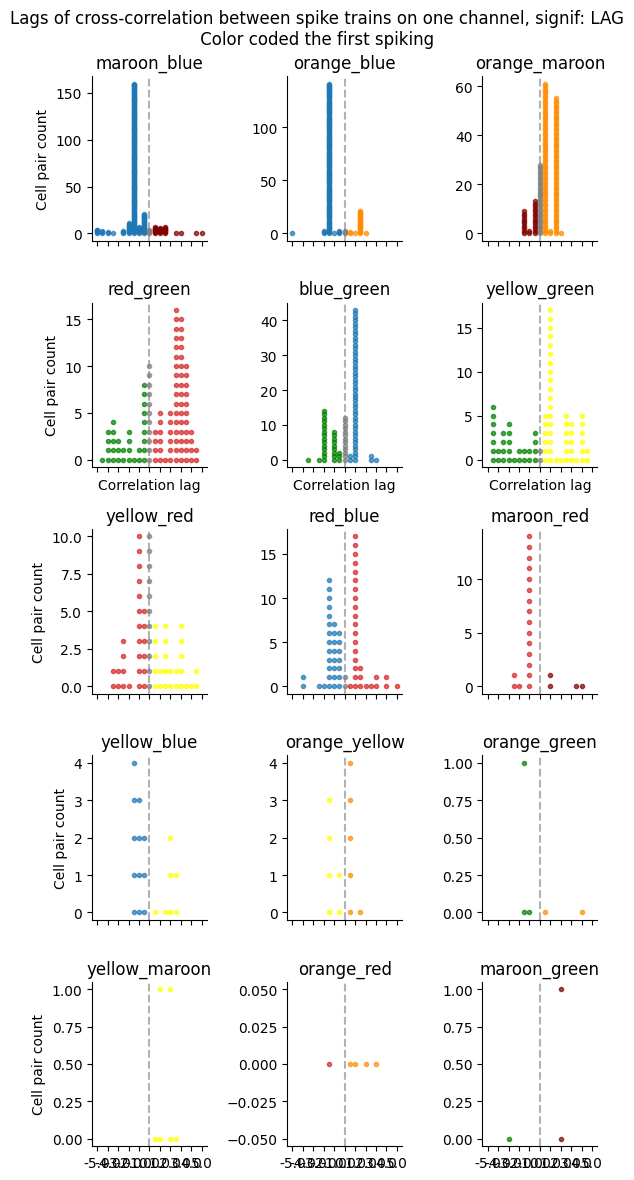

In [27]:
erase_same_cl = True
erase_small_gr = False

only_max_signif = False
only_lag_signif = True
both_signif = False

lag_name = 'sorted_lags'

fig, ax = plt.subplots(5,3,sharex=True,sharey=False)
fig.set_figwidth(6)
fig.set_figheight(12)


# FILTERING BASED ON SIGNIFICANCE OF LAGS
if only_max_signif:
    signif_option = 'MAX'
    df = df_pairs[df_pairs['signif_at_max']] 
elif only_lag_signif:
    signif_option = 'LAG'
    df = df_pairs[df_pairs['signif_at_lag']]
elif both_signif:
    signif_option = 'BOTH'
    df = df_pairs[df_pairs['signif_at_max']]
    df = df[df['signif_at_lag']]
else:
    signif_option = 'NONE'
    df = df_pairs

plt.suptitle(f'Lags of cross-correlation between spike trains on one channel, signif: {signif_option}\n Color coded the first spiking ')

same_groups = ['green_green','yellow_yellow','red_red','blue_blue','orange_orange','maroon_maroon']
small_groups = ['blue_green','maroon_green','maroon_red','orange_green','orange_red',
                'orange_yellow','red_blue','yellow_blue', 'yellow_green', 'yellow_red']

if erase_same_cl:  # not showing lags between the same type of units
    df = df[~df['pair_class'].isin(same_groups)]

if erase_small_gr:
    df = df[~df['pair_class'].isin(small_groups)]

count_df = df['pair_class'].value_counts().reset_index()
count_df.columns = ['pair_class', 'Count']
#count_df = count_df.sort_values('pair_class')  # Ensure consistent order

for i, cl in enumerate(count_df['pair_class']):
    col = i%3
    row = i//3

    df_cl = df[df['pair_class'] == cl]
    values = df_cl[lag_name].dropna().values
    cl1, cl2 = cl.split('_', 1)

    # Count values per bin
    bin_centers = np.arange(-10, 11, 1)  # includes 5
    bin_edges = bin_centers - 0.5
    bin_edges = np.append(bin_edges, bin_centers[-1] + 0.5)

    counts, _ = np.histogram(values, bins=bin_edges)

    # Plot stacked dots
    for x, count in zip(bin_centers, counts):
        if x<0:
            color = cl2 
        elif x>0:
            color = cl1
        else:
            color='gray'
        # changing colors for those who does not exactly match
        if color=='blue':
            color='tab:blue'
        if color=='red':
            color='tab:red'
        if color=='orange':
            color='darkorange'
        ax[row][col].plot([x]*count, range(count), 'o', color=color, alpha=0.7, markersize=3)
        ax[row][col].set_title(cl)
    
    #ax[row][col].hist(df_cl[lag_name])
    ax[row][col].axvline(0,ls='dashed',alpha=0.6,color='gray')

    ax[row][col].spines['top'].set_visible(False)
    ax[row][col].spines['right'].set_visible(False)
    #ax[row][col].spines['bottom'].set_visible(False)
    ax[row][col].set_xticks(np.arange(-10, 11, 2))
    ax[row][col].set_xticklabels([f"{x:.1f}" for x in np.arange(-5, 5.5, 1)])

    ax[row][col].set_xlabel('')
    if col==0:
        ax[row][col].set_ylabel('Cell pair count')
    if row==1:
        ax[row][col].set_xlabel('Correlation lag')
    #ax[row][col].legend()

plt.tight_layout()
#plt.legend()
plt.show()
plt.close()

### Lags 4 classes only

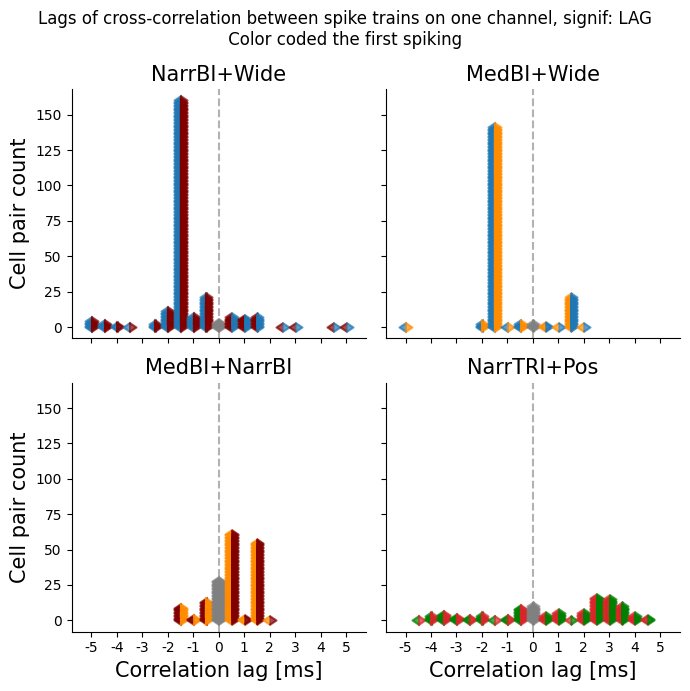

In [28]:
erase_same_cl = True
erase_small_gr = False

only_max_signif = False
only_lag_signif = True
both_signif = False

lag_name = 'sorted_lags'

fig, ax = plt.subplots(2,2,sharex=True,sharey=True)
fig.set_figwidth(7)
fig.set_figheight(7)


# FILTERING BASED ON SIGNIFICANCE OF LAGS
if only_max_signif:
    signif_option = 'MAX'
    df = df_pairs[df_pairs['signif_at_max']] 
elif only_lag_signif:
    signif_option = 'LAG'
    df = df_pairs[df_pairs['signif_at_lag']]
elif both_signif:
    signif_option = 'BOTH'
    df = df_pairs[df_pairs['signif_at_max']]
    df = df[df['signif_at_lag']]
else:
    signif_option = 'NONE'
    df = df_pairs

plt.suptitle(f'Lags of cross-correlation between spike trains on one channel, signif: {signif_option}\n Color coded the first spiking ')

same_groups = ['green_green','yellow_yellow','red_red','blue_blue','orange_orange','maroon_maroon']
small_groups = ['blue_green','maroon_green','maroon_red','orange_green','orange_red',
                'orange_yellow','red_blue','yellow_blue','yellow_green','yellow_red']

if erase_same_cl:  # not showing lags between the same type of units
    df = df[~df['pair_class'].isin(same_groups)]

if erase_small_gr:
    df = df[~df['pair_class'].isin(small_groups)]

count_df = df['pair_class'].value_counts().reset_index()
count_df.columns = ['pair_class', 'Count']
#count_df = count_df.sort_values('pair_class')  # Ensure consistent order

cl_list_four = ['maroon_blue','orange_blue','orange_maroon','red_green']

for i, cl in enumerate(cl_list_four): #enumerate(count_df['pair_class']):
    col = i%2
    row = i//2

    df_cl = df[df['pair_class'] == cl]
    values = df_cl[lag_name].dropna().values
    cl1, cl2 = cl.split('_', 1)

    # Count values per bin
    bin_centers = np.arange(-10, 11, 1)  # includes 5
    bin_edges = bin_centers - 0.5
    bin_edges = np.append(bin_edges, bin_centers[-1] + 0.5)

    counts, _ = np.histogram(values, bins=bin_edges)

    # Plot stacked dots
    for x, count in zip(bin_centers, counts):
        if x<0:
            color_first = cl2 
            color_second = cl1
        elif x>0:
            color_first = cl1
            color_second = cl2
        else:
            color_first='gray'
            color_second = 'gray'
        # changing colors for those who does not exactly match
        if color_first=='blue':
            color_first='tab:blue'
        if color_first=='red':
            color_first='tab:red'
        if color_first=='orange':
            color_first='darkorange'
        if color_second=='blue':
            color_second='tab:blue'
        if color_second=='red':
            color_second='tab:red'
        if color_second=='orange':
            color_second='darkorange'
        if x<0:
            ax[row][col].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=50)  # left part, first spike
            ax[row][col].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=50)  # left part, second spike
        elif x==0:
            ax[row][col].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=45)  # middle
            ax[row][col].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=45)  # middle
        else:
            ax[row][col].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=45)  # right part, first spike
            ax[row][col].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=45)  # right part, second spike
        cl_names = CELL_PAIRS_MAPPING
        ax[row][col].set_title(cl_names[cl],fontsize=15)
    
    #ax[row][col].hist(df_cl[lag_name])
    ax[row][col].axvline(0,ls='dashed',alpha=0.6,color='gray')

    ax[row][col].spines['top'].set_visible(False)
    ax[row][col].spines['right'].set_visible(False)
    #ax[row][col].spines['bottom'].set_visible(False)
    ax[row][col].set_xticks(np.arange(-10, 11, 2))  # lags are in the units of 0.5 ms 
    ax[row][col].set_xticklabels([f"{x:.0f}" for x in np.arange(-5, 5.5, 1)])  # this is important, for conversion of the lag

    ax[row][col].set_xlabel('')
    if col==0:
        ax[row][col].set_ylabel('Cell pair count',fontsize=15)
    if row==1:
        ax[row][col].set_xlabel('Correlation lag [ms]',fontsize=15)
    #ax[row][col].legend()

plt.tight_layout()
#plt.legend()
plt.show()
plt.close()

### Less numerous classes lags 

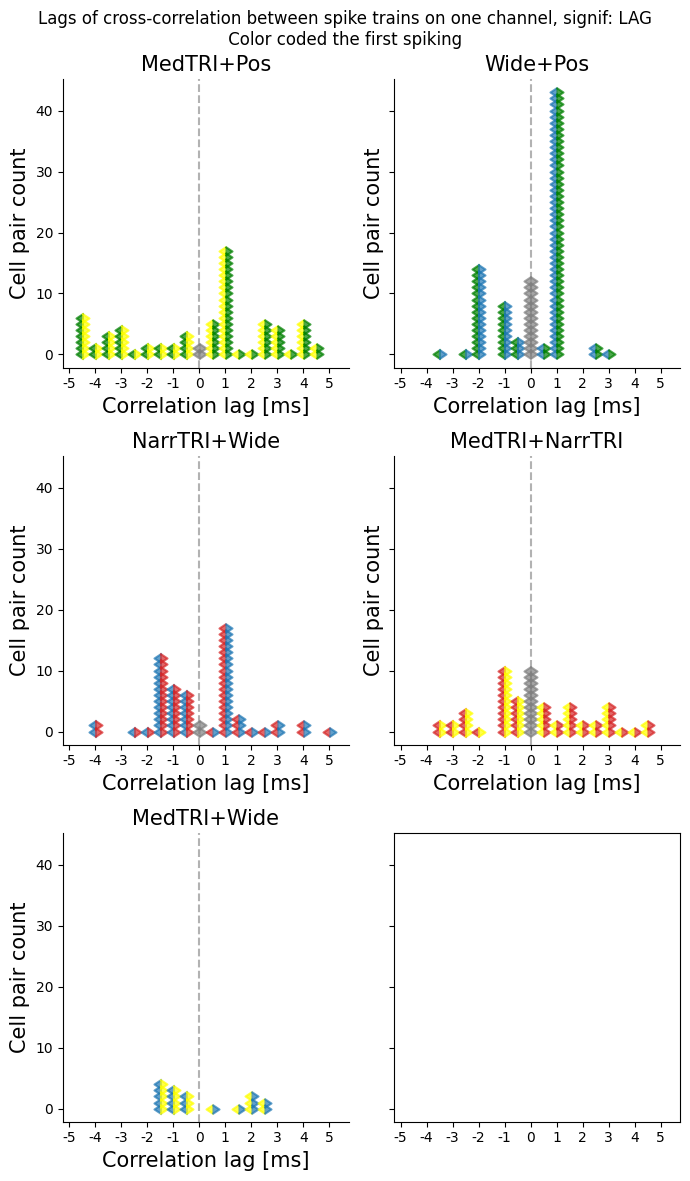

In [29]:
erase_same_cl = True
erase_small_gr = False

only_max_signif = False
only_lag_signif = True
both_signif = False

lag_name = 'sorted_lags'

"""
FOR ALL PAIR TYPES, INCLUDING MIXED LAYERS

fig, ax = plt.subplots(6,2,sharex=True,sharey=True)
fig.set_figwidth(7)
fig.set_figheight(23)
"""

fig, ax = plt.subplots(3,2,sharex=True,sharey=True)
fig.set_figwidth(7)
fig.set_figheight(12)


# FILTERING BASED ON SIGNIFICANCE OF LAGS
if only_max_signif:
    signif_option = 'MAX'
    df = df_pairs[df_pairs['signif_at_max']] 
elif only_lag_signif:
    signif_option = 'LAG'
    df = df_pairs[df_pairs['signif_at_lag']]
elif both_signif:
    signif_option = 'BOTH'
    df = df_pairs[df_pairs['signif_at_max']]
    df = df[df['signif_at_lag']]
else:
    signif_option = 'NONE'
    df = df_pairs

plt.suptitle(f'Lags of cross-correlation between spike trains on one channel, signif: {signif_option}\n Color coded the first spiking ')

same_groups = ['green_green','yellow_yellow','red_red','blue_blue','orange_orange','maroon_maroon']
small_groups = ['blue_green','maroon_green','maroon_red','orange_green','orange_red',
                'orange_yellow','red_blue','yellow_blue','yellow_green','yellow_red']

if erase_same_cl:  # not showing lags between the same type of units
    df = df[~df['pair_class'].isin(same_groups)]

if erase_small_gr:
    df = df[~df['pair_class'].isin(small_groups)]

count_df = df['pair_class'].value_counts().reset_index()
count_df.columns = ['pair_class', 'Count']
#count_df = count_df.sort_values('pair_class')  # Ensure consistent order

cl_list_other = ['yellow_green','blue_green','red_blue','yellow_red','yellow_blue']

"""
ALL PAIR TYPES, ALSO CROSS LAYER

['yellow_green','blue_green','red_blue','yellow_red','yellow_blue','orange_yellow',
                 'maroon_red','yellow_maroon','orange_red','orange_green','maroon_green']
"""

for i, cl in enumerate(cl_list_other): #enumerate(count_df['pair_class']):
    col = i%2
    row = i//2

    df_cl = df[df['pair_class'] == cl]
    values = df_cl[lag_name].dropna().values
    cl1, cl2 = cl.split('_', 1)

    # Count values per bin
    bin_centers = np.arange(-10, 11, 1)  # includes 5
    bin_edges = bin_centers - 0.5
    bin_edges = np.append(bin_edges, bin_centers[-1] + 0.5)

    counts, _ = np.histogram(values, bins=bin_edges)

    # Plot stacked dots
    for x, count in zip(bin_centers, counts):
        if x<0:
            color_first = cl2 
            color_second = cl1
        elif x>0:
            color_first = cl1
            color_second = cl2
        else:
            color_first='gray'
            color_second = 'gray'
        # changing colors for those who does not exactly match
        if color_first=='blue':
            color_first='tab:blue'
        if color_first=='red':
            color_first='tab:red'
        if color_first=='orange':
            color_first='darkorange'
        if color_second=='blue':
            color_second='tab:blue'
        if color_second=='red':
            color_second='tab:red'
        if color_second=='orange':
            color_second='darkorange'
        if x<0:
            ax[row][col].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=50)  # left part, first spike
            ax[row][col].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=50)  # left part, second spike
        elif x==0:
            ax[row][col].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=45)  # middle
            ax[row][col].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=45)  # middle
        else:
            ax[row][col].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=45)  # right part, first spike
            ax[row][col].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=45)  # right part, second spike
        cl_names = CELL_PAIRS_MAPPING
        ax[row][col].set_title(cl_names[cl],fontsize=15)
    
    #ax[row][col].hist(df_cl[lag_name])
    ax[row][col].axvline(0,ls='dashed',alpha=0.6,color='gray')

    ax[row][col].spines['top'].set_visible(False)
    ax[row][col].spines['right'].set_visible(False)
    #ax[row][col].spines['bottom'].set_visible(False)
    ax[row][col].tick_params(labelbottom=True)
    ax[row][col].set_xticks(np.arange(-10, 11, 2))  # lags are in the units of 0.5 ms 
    ax[row][col].set_xticklabels([f"{x:.0f}" for x in np.arange(-5, 5.5, 1)])  # this is important, for conversion of the lag

    ax[row][col].set_xlabel('')
    ax[row][col].set_ylabel('Cell pair count',fontsize=15)
    ax[row][col].set_xlabel('Correlation lag [ms]',fontsize=15)
    #ax[row][col].legend()

plt.tight_layout()
#plt.legend()
plt.show()
plt.close()

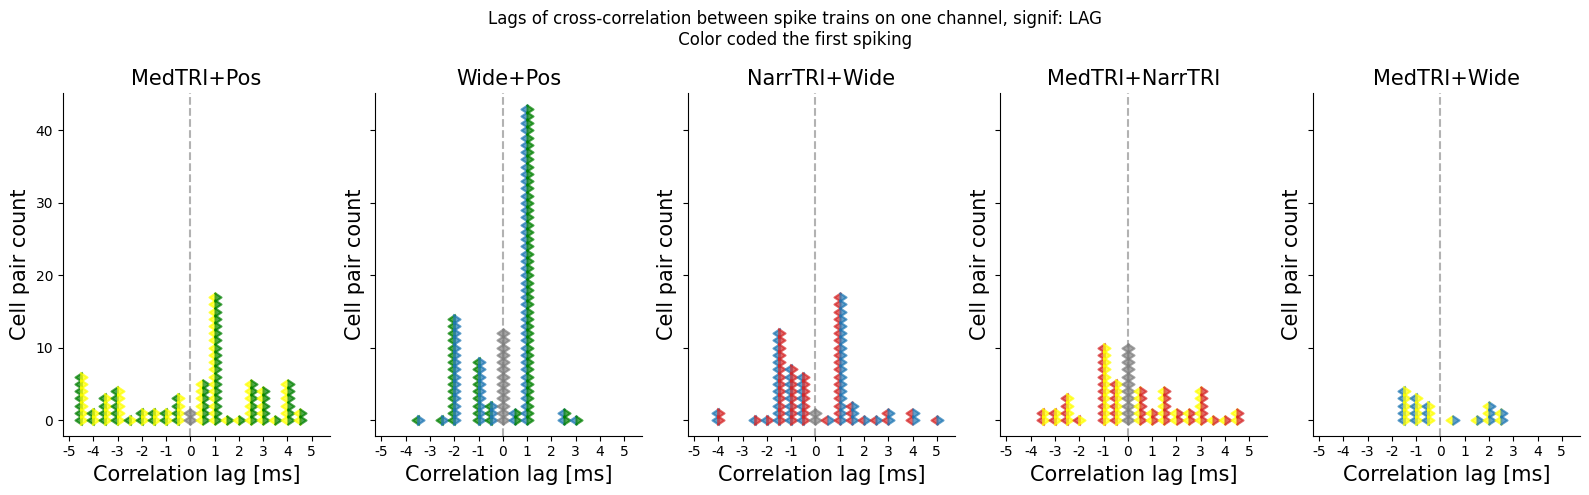

In [30]:
erase_same_cl = True
erase_small_gr = False

only_max_signif = False
only_lag_signif = True
both_signif = False

lag_name = 'sorted_lags'

"""
FOR ALL PAIR TYPES, INCLUDING MIXED LAYERS

fig, ax = plt.subplots(6,2,sharex=True,sharey=True)
fig.set_figwidth(7)
fig.set_figheight(23)
"""

fig, ax = plt.subplots(1,5,sharex=True,sharey=True)
fig.set_figwidth(16)
fig.set_figheight(5)


# FILTERING BASED ON SIGNIFICANCE OF LAGS
if only_max_signif:
    signif_option = 'MAX'
    df = df_pairs[df_pairs['signif_at_max']] 
elif only_lag_signif:
    signif_option = 'LAG'
    df = df_pairs[df_pairs['signif_at_lag']]
elif both_signif:
    signif_option = 'BOTH'
    df = df_pairs[df_pairs['signif_at_max']]
    df = df[df['signif_at_lag']]
else:
    signif_option = 'NONE'
    df = df_pairs

plt.suptitle(f'Lags of cross-correlation between spike trains on one channel, signif: {signif_option}\n Color coded the first spiking ')

same_groups = ['green_green','yellow_yellow','red_red','blue_blue','orange_orange','maroon_maroon']
small_groups = ['blue_green','maroon_green','maroon_red','orange_green','orange_red',
                'orange_yellow','red_blue','yellow_blue','yellow_green','yellow_red']

if erase_same_cl:  # not showing lags between the same type of units
    df = df[~df['pair_class'].isin(same_groups)]

if erase_small_gr:
    df = df[~df['pair_class'].isin(small_groups)]

count_df = df['pair_class'].value_counts().reset_index()
count_df.columns = ['pair_class', 'Count']
#count_df = count_df.sort_values('pair_class')  # Ensure consistent order

cl_list_other = ['yellow_green','blue_green','red_blue','yellow_red','yellow_blue']

for i, cl in enumerate(cl_list_other): #enumerate(count_df['pair_class']):
    df_cl = df[df['pair_class'] == cl]
    values = df_cl[lag_name].dropna().values
    cl1, cl2 = cl.split('_', 1)

    # Count values per bin
    bin_centers = np.arange(-10, 11, 1)  # includes 5
    bin_edges = bin_centers - 0.5
    bin_edges = np.append(bin_edges, bin_centers[-1] + 0.5)

    counts, _ = np.histogram(values, bins=bin_edges)

    # Plot stacked dots
    for x, count in zip(bin_centers, counts):
        if x<0:
            color_first = cl2 
            color_second = cl1
        elif x>0:
            color_first = cl1
            color_second = cl2
        else:
            color_first='gray'
            color_second = 'gray'
        # changing colors for those who does not exactly match
        if color_first=='blue':
            color_first='tab:blue'
        if color_first=='red':
            color_first='tab:red'
        if color_first=='orange':
            color_first='darkorange'
        if color_second=='blue':
            color_second='tab:blue'
        if color_second=='red':
            color_second='tab:red'
        if color_second=='orange':
            color_second='darkorange'
        if x<0:
            ax[i].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=50)  # left part, first spike
            ax[i].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=50)  # left part, second spike
        elif x==0:
            ax[i].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=45)  # middle
            ax[i].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=45)  # middle
        else:
            ax[i].scatter([x-0.5]*count, range(count), marker=4, color=color_first, alpha=0.7, s=45)  # right part, first spike
            ax[i].scatter([x+0.5]*count, range(count), marker=5, color=color_second, alpha=0.7, s=45)  # right part, second spike
        cl_names = CELL_PAIRS_MAPPING
        ax[i].set_title(cl_names[cl],fontsize=15)
    
    ax[i].axvline(0,ls='dashed',alpha=0.6,color='gray')

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelbottom=True)
    ax[i].set_xticks(np.arange(-10, 11, 2))  # lags are in the units of 0.5 ms 
    ax[i].set_xticklabels([f"{x:.0f}" for x in np.arange(-5, 5.5, 1)])  # this is important, for conversion of the lag

    ax[i].set_xlabel('')
    ax[i].set_ylabel('Cell pair count',fontsize=15)
    ax[i].set_xlabel('Correlation lag [ms]',fontsize=15)

plt.tight_layout()
#plt.legend()
plt.show()
plt.close()